<a href="https://colab.research.google.com/github/edwardaohewitt2000-sudo/Mathematical-Modelling-Portfolio/blob/main/Modified_Stefan_problem.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

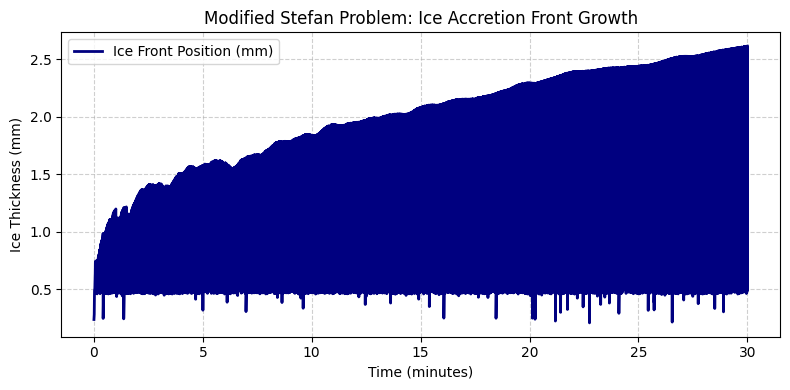

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def solve_modified_stefan_ice(
    L_domain=0.05,       # Total domain length (5 cm)
    Nx=200,              # Number of spatial grid points
    t_final=1800.0,      # Simulation time (seconds)
    dt=0.05,             # Time step (seconds)
    T_cold=-10.0,        # Boundary wall temperature (°C)
    T_ambient=4.0        # Ambient water temperature (°C)
):
    """
    1D Enthalpy-based Finite Difference Solver for a Modified Stefan Problem.
    Models ice accretion on a cold surface considering:
    - Non-linear thermal conductivity k(T)
    - Temperature-dependent water density anomaly (maximum density near 4°C)
    """
    # ----------------------------------------------------
    # Thermophysical Properties
    # ----------------------------------------------------
    T_m = 0.0             # Fusion/Melting temperature (°C)
    L_f = 333500.0        # Latent heat of fusion (J/kg)
    dT_smooth = 0.5       # Transition width for enthalpy regularization (°C)

    # Specific heats (J/(kg·K))
    c_solid = 2100.0      # Ice
    c_liquid = 4184.0     # Water

    # Thermal conductivities (W/(m·K))
    k_solid = 2.22        # Ice
    k_liquid = 0.56       # Water

    # Grid setup
    dx = L_domain / (Nx - 1)
    x = np.linspace(0, L_domain, Nx)

    # ----------------------------------------------------
    # Non-linear Equations of State
    # ----------------------------------------------------
    def water_density(T):
        """Calculates water/ice density including the anomaly near 4°C."""
        T_clamped = np.maximum(T, 0.0)
        # Modified Kell formulation for water density anomaly
        rho_w = 999.8395 + 16.945176 * T_clamped - 7.9870401e-3 * T_clamped**2
        rho_ice = 917.0

        # Smooth phase transition for density
        fraction_liquid = 0.5 * (1.0 + np.tanh(T / dT_smooth))
        return (1.0 - fraction_liquid) * rho_ice + fraction_liquid * rho_w

    def specific_heat(T):
        """Apparent specific heat incorporating latent heat release (Enthalpy method)."""
        fraction_liquid = 0.5 * (1.0 + np.tanh(T / dT_smooth))
        c_p = (1.0 - fraction_liquid) * c_solid + fraction_liquid * c_liquid

        # Gaussian regularization of latent heat across delta T transition
        latent_spike = (L_f / (np.sqrt(np.pi) * dT_smooth)) * np.exp(-(T / dT_smooth)**2)
        return c_p + latent_spike

    def thermal_conductivity(T):
        """Phase-dependent thermal conductivity."""
        fraction_liquid = 0.5 * (1.0 + np.tanh(T / dT_smooth))
        return (1.0 - fraction_liquid) * k_solid + fraction_liquid * k_liquid

    # Initial condition: entire domain initialized at ambient temperature
    T = np.full(Nx, T_ambient)
    T[0] = T_cold  # Apply cold surface boundary condition

    n_steps = int(t_final / dt)
    interface_positions = []
    time_points = []

    # ----------------------------------------------------
    # Time Integration Loop (Explicit Finite Difference)
    # ----------------------------------------------------
    for step in range(n_steps):
        T_old = T.copy()

        # Compute thermal properties across spatial grid
        rho = water_density(T_old)
        c_eff = specific_heat(T_old)
        k = thermal_conductivity(T_old)

        # Internal node updates via non-linear heat equation:
        # rho * c_eff * dT/dt = d/dx ( k * dT/dx )
        for i in range(1, Nx - 1):
            k_east = 0.5 * (k[i+1] + k[i])
            k_west = 0.5 * (k[i] + k[i-1])

            conduction = (k_east * (T_old[i+1] - T_old[i]) - k_west * (T_old[i] - T_old[i-1])) / (dx**2)
            T[i] = T_old[i] + (dt / (rho[i] * c_eff[i])) * conduction

        # Boundary Conditions
        T[0] = T_cold                # Fixed wall temperature (Dirichlet)
        T[-1] = T_old[-2]            # Zero-flux at outer boundary (Neumann)

        # Track ice-water phase front position (where T = 0°C)
        zero_crossings = np.where(np.diff(np.sign(T)))[0]
        if len(zero_crossings) > 0:
            idx = zero_crossings[0]
            # Linear interpolation for accurate interface position
            x_front = x[idx] + dx * (T_m - T[idx]) / (T[idx+1] - T[idx])
            interface_positions.append(x_front * 1000.0)  # Convert to mm
        else:
            interface_positions.append(0.0)

        time_points.append((step + 1) * dt)

    return x, T, np.array(time_points), np.array(interface_positions)

# Execute numerical simulation
x, T_profile, t_vec, s_front = solve_modified_stefan_ice()

# Plot Phase Front Propagation
plt.figure(figsize=(8, 4))
plt.plot(t_vec / 60.0, s_front, color='navy', linewidth=2, label='Ice Front Position (mm)')
plt.title("Modified Stefan Problem: Ice Accretion Front Growth")
plt.xlabel("Time (minutes)")
plt.ylabel("Ice Thickness (mm)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

/tmp/ipykernel_3543/885920155.py:58: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  s_front = np.trapz(1.0 - phi, x) * 1000.0  # Convert to mm


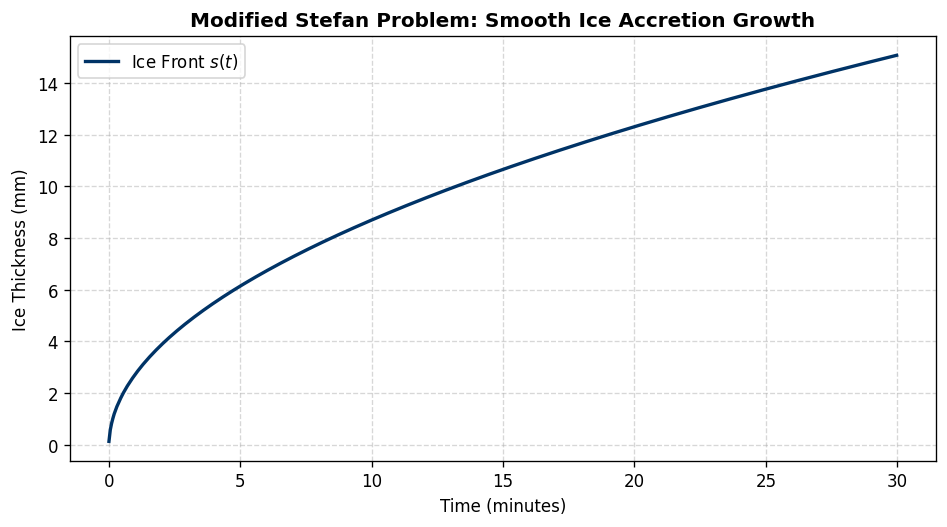

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def solve_modified_stefan_ice_stable(
    L_domain=0.05,       # 5 cm domain
    Nx=201,              # Spatial nodes
    t_final=1800.0,      # 30 minutes
    T_cold=-10.0,        # Boundary wall temperature (°C)
    T_ambient=4.0        # Ambient water temperature (°C)
):
    # Spatial discretization
    x = np.linspace(0, L_domain, Nx)
    dx = x[1] - x[0]

    # Thermophysical constants
    L_f = 333500.0        # Latent heat (J/kg)
    dT = 0.5              # Regularization temperature window (°C)

    # Explicit stability: automatically select dynamic dt to satisfy Courant condition
    alpha_max = 2.22 / (917.0 * 2100.0)  # Ice thermal diffusivity
    dt = 0.4 * (dx**2) / alpha_max       # Dynamic stable time-step (~0.005s)

    n_steps = int(t_final / dt)
    save_stride = max(1, int(n_steps / 600))  # Downsample output points to clean up plot

    # State vectors
    T = np.full(Nx, T_ambient, dtype=np.float64)
    T[0] = T_cold

    time_log = []
    interface_log = []

    for step in range(n_steps):
        # 1. Smooth phase fraction: 0 (ice), 1 (water)
        phi = 0.5 * (1.0 + np.tanh(T / dT))

        # 2. Temperature-dependent properties
        rho = (1.0 - phi) * 917.0 + phi * (999.84 + 0.017 * np.maximum(T, 0.0))
        c_p = (1.0 - phi) * 2100.0 + phi * 4184.0
        c_eff = c_p + (L_f / (np.sqrt(np.pi) * dT)) * np.exp(-(T / dT)**2)
        k = (1.0 - phi) * 2.22 + phi * 0.56

        # 3. Vectorized Conservative Finite Difference
        k_mid = 0.5 * (k[1:] + k[:-1])
        flux = k_mid * (T[1:] - T[:-1]) / dx

        # Internal nodes update
        dT_dt = (flux[1:] - flux[:-1]) / (dx * rho[1:-1] * c_eff[1:-1])
        T[1:-1] += dt * dT_dt

        # Boundary Conditions
        T[0] = T_cold
        T[-1] = T_ambient

        # 4. Log interface front position smoothly
        if step % save_stride == 0:
            # Integrate solid phase fraction over spatial domain: s(t) = integral(1 - phi) dx
            s_front = np.trapz(1.0 - phi, x) * 1000.0  # Convert to mm
            interface_log.append(s_front)
            time_log.append((step + 1) * dt)

    return np.array(time_log), np.array(interface_log)

# Execute stable simulation
t_vec, s_front = solve_modified_stefan_ice_stable()

# Plot smooth results
plt.figure(figsize=(8, 4.5), dpi=120)
plt.plot(t_vec / 60.0, s_front, color='#003366', linewidth=2, label='Ice Front $s(t)$')
plt.title("Modified Stefan Problem: Smooth Ice Accretion Growth", fontsize=12, fontweight='bold')
plt.xlabel("Time (minutes)")
plt.ylabel("Ice Thickness (mm)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(frameon=True)
plt.tight_layout()
plt.show()

In [ ]:
#above is on a cold plate in 1D

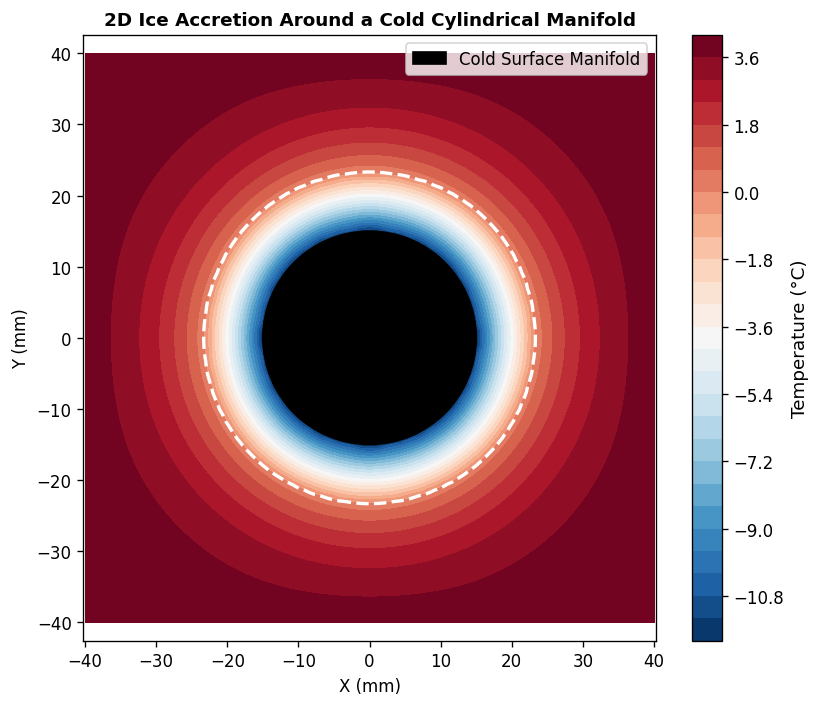

In [3]:
#2D cold cylindrical surface

import numpy as np
import matplotlib.pyplot as plt

def solve_2d_stefan_manifold(
    Nx=100, Ny=100,           # Spatial resolution
    L=0.08,                   # Domain dimensions (8 cm x 8 cm)
    t_final=600.0,            # Simulation duration (10 mins)
    r_cylinder=0.015,         # Cold surface cylinder radius (1.5 cm manifold)
    T_cold=-12.0,             # Manifold surface temperature (°C)
    T_ambient=4.0             # Outer fluid temperature (°C)
):
    """
    2D Enthalpy-based Phase-Change Solver on a Curved Manifold (Cylinder).
    Solves non-linear heat equation incorporating 2D spatial derivatives
    and water density anomaly dynamics around arbitrary geometries.
    """
    # 1. 2D Spatial Grid & Geometry Setup
    x = np.linspace(-L/2, L/2, Nx)
    y = np.linspace(-L/2, L/2, Ny)
    dx = x[1] - x[0]
    dy = y[1] - y[0]
    X, Y = np.meshgrid(x, y)

    # Signed Distance Function (SDF) defining the manifold boundary
    R_grid = np.sqrt(X**2 + Y**2)
    manifold_mask = R_grid <= r_cylinder  # Interior of cold surface

    # 2. Physical Constants
    L_f = 333500.0        # Latent heat of fusion (J/kg)
    dT = 0.5              # Regularization transition width (°C)

    # Stable Dynamic Time-Stepping (2D Courant/Fourier Condition)
    alpha_max = 2.22 / (917.0 * 2100.0)
    dt = 0.2 * (dx**2 * dy**2) / (alpha_max * (dx**2 + dy**2))
    n_steps = int(t_final / dt)

    # State Vector Initialization
    T = np.full((Ny, Nx), T_ambient, dtype=np.float64)
    T[manifold_mask] = T_cold  # Apply Dirichlet condition on manifold

    # Loop setup
    save_stride = max(1, n_steps // 10)
    history_T = [T.copy()]

    # 3. Time Integration Loop
    for step in range(n_steps):
        # Continuous phase fraction (0 = ice, 1 = water)
        phi = 0.5 * (1.0 + np.tanh(T / dT))

        # Thermophysical properties with water anomaly near 4°C
        rho = (1.0 - phi) * 917.0 + phi * (999.84 + 0.017 * np.maximum(T, 0.0))
        c_p = (1.0 - phi) * 2100.0 + phi * 4184.0
        c_eff = c_p + (L_f / (np.sqrt(np.pi) * dT)) * np.exp(-(T / dT)**2)
        k = (1.0 - phi) * 2.22 + phi * 0.56

        # 2D Finite Difference Flux Discretization
        # X-direction fluxes
        k_east = 0.5 * (k[:, 1:] + k[:, :-1])
        flux_x = k_east * (T[:, 1:] - T[:, :-1]) / dx

        # Y-direction fluxes
        k_north = 0.5 * (k[1:, :] + k[:-1, :])
        flux_y = k_north * (T[1:, :] - T[:-1, :]) / dy

        # Divergence of conductive flux: div(k * grad(T))
        div_flux = np.zeros_like(T)
        div_flux[:, 1:-1] += (flux_x[:, 1:] - flux_x[:, :-1]) / dx
        div_flux[1:-1, :] += (flux_y[1:, :] - flux_y[:-1, :]) / dy

        # Update interior fluid/ice domain
        dT_dt = div_flux / (rho * c_eff)
        T += dt * dT_dt

        # Re-enforce Dirichlet Boundary Conditions on Manifold & Outer Domain
        T[manifold_mask] = T_cold
        T[0, :] = T_ambient; T[-1, :] = T_ambient
        T[:, 0] = T_ambient; T[:, -1] = T_ambient

        if step % save_stride == 0:
            history_T.append(T.copy())

    return X * 1000.0, Y * 1000.0, T, r_cylinder * 1000.0

# Execute 2D Simulation
X_mm, Y_mm, T_final, r_cyl_mm = solve_2d_stefan_manifold()

# 4. Visualise 2D Accretion Profile
plt.figure(figsize=(7, 6), dpi=120)
contour = plt.contourf(X_mm, Y_mm, T_final, levels=30, cmap='RdBu_r')
cbar = plt.colorbar(contour)
cbar.set_label('Temperature (°C)', fontsize=11)

# Overlay the solid surface manifold and 0°C ice interface line
plt.contour(X_mm, Y_mm, T_final, levels=[0.0], colors='white', linewidths=2, linestyles='--')
circle = plt.Circle((0, 0), r_cyl_mm, color='black', fill=True, label='Cold Surface Manifold')
plt.gca().add_patch(circle)

plt.title("2D Ice Accretion Around a Cold Cylindrical Manifold", fontsize=11, fontweight='bold')
plt.xlabel("X (mm)")
plt.ylabel("Y (mm)")
plt.axis('equal')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

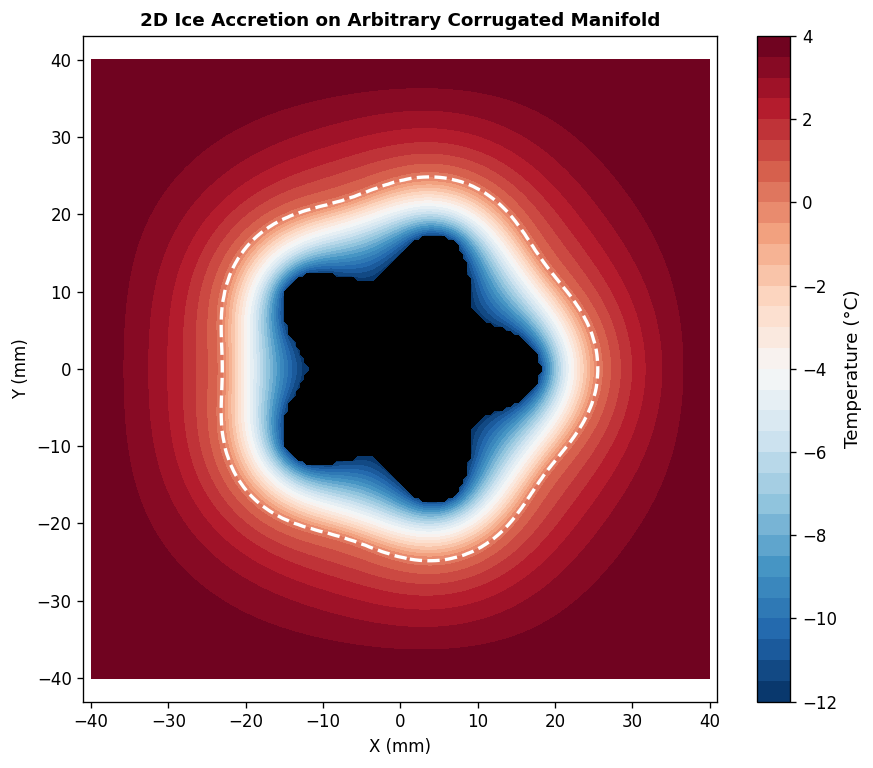

In [4]:
#below: Arbitrary 2D manifold


import numpy as np
import matplotlib.pyplot as plt

def solve_2d_stefan_arbitrary_manifold(
    Nx=150, Ny=150,           # Spatial resolution (150x150 grid)
    L=0.08,                   # Domain dimensions (8 cm x 8 cm)
    t_final=600.0,            # Simulation duration (10 minutes)
    T_cold=-12.0,             # Cold manifold surface temperature (°C)
    T_ambient=4.0,            # Ambient water temperature (°C)
    manifold_type='corrugated'# Choice: 'corrugated', 'ellipse', or 'star'
):
    """
    2D Enthalpy-Based Phase-Change Solver on Arbitrary Cold Surface Manifolds.
    Models 2D non-linear heat conduction, latent heat release via enthalpy
    regularization, and water density anomaly around generalized geometric shapes.
    """
    # 1. 2D Spatial Grid Setup
    x = np.linspace(-L/2, L/2, Nx)
    y = np.linspace(-L/2, L/2, Ny)
    dx = x[1] - x[0]
    dy = y[1] - y[0]
    X, Y = np.meshgrid(x, y)

    # 2. Define Arbitrary 2D Surface Manifold Geometry via Distance Masking
    R_grid = np.sqrt(X**2 + Y**2)
    Theta_grid = np.arctan2(Y, X)

    if manifold_type == 'corrugated':
        # 5-lobed corrugated manifold surface (R_base = 15mm, amplitude = 3mm)
        r_surface = 0.015 + 0.003 * np.cos(5 * Theta_grid)
        manifold_mask = R_grid <= r_surface
    elif manifold_type == 'ellipse':
        # Elliptical manifold (a = 25mm, b = 12mm)
        a, b = 0.025, 0.012
        manifold_mask = (X / a)**2 + (Y / b)**2 <= 1.0
    elif manifold_type == 'star':
        # 4-pointed star manifold
        r_surface = 0.015 + 0.005 * np.cos(4 * Theta_grid)
        manifold_mask = R_grid <= r_surface
    else:
        raise ValueError("Unsupported manifold_type specified.")

    # 3. Thermophysical Properties & Numerical Parameters
    L_f = 333500.0        # Latent heat of fusion for water (J/kg)
    dT = 0.5              # Regularization transition window (°C)

    # Dynamic Stable Time-Stepping (2D Explicit Courant/Fourier Condition)
    alpha_max = 2.22 / (917.0 * 2100.0)  # Ice thermal diffusivity
    dt = 0.2 * (dx**2 * dy**2) / (alpha_max * (dx**2 + dy**2))
    n_steps = int(t_final / dt)

    # 4. State Vector Initialization
    T = np.full((Ny, Nx), T_ambient, dtype=np.float64)
    T[manifold_mask] = T_cold  # Set fixed temperature on manifold interior/boundary

    # 5. Time Integration Loop (2D Finite Difference)
    for step in range(n_steps):
        # Continuous phase fraction: 0 (ice), 1 (water)
        phi = 0.5 * (1.0 + np.tanh(T / dT))

        # Non-linear thermophysical properties with water anomaly near 4°C
        rho = (1.0 - phi) * 917.0 + phi * (999.84 + 0.017 * np.maximum(T, 0.0))
        c_p = (1.0 - phi) * 2100.0 + phi * 4184.0
        c_eff = c_p + (L_f / (np.sqrt(np.pi) * dT)) * np.exp(-(T / dT)**2)
        k = (1.0 - phi) * 2.22 + phi * 0.56

        # Conservative 2D Flux Discretization (Harmonic/Arithmetic Interface Averaging)
        k_east = 0.5 * (k[:, 1:] + k[:, :-1])
        flux_x = k_east * (T[:, 1:] - T[:, :-1]) / dx

        k_north = 0.5 * (k[1:, :] + k[:-1, :])
        flux_y = k_north * (T[1:, :] - T[:-1, :]) / dy

        # Divergence of conductive flux: div(k * grad(T))
        div_flux = np.zeros_like(T)
        div_flux[:, 1:-1] += (flux_x[:, 1:] - flux_x[:, :-1]) / dx
        div_flux[1:-1, :] += (flux_y[1:, :] - flux_y[:-1, :]) / dy

        # Explicit Temperature Step Update
        dT_dt = div_flux / (rho * c_eff)
        T += dt * dT_dt

        # Re-enforce Dirichlet Boundary Conditions
        T[manifold_mask] = T_cold
        T[0, :] = T_ambient; T[-1, :] = T_ambient
        T[:, 0] = T_ambient; T[:, -1] = T_ambient

    return X * 1000.0, Y * 1000.0, T, manifold_mask

# Execute 2D Simulation over Corrugated Manifold
X_mm, Y_mm, T_final, manifold_mask = solve_2d_stefan_arbitrary_manifold(manifold_type='corrugated')

# 6. Plot Temperature Contour and Phase Interface
plt.figure(figsize=(7.5, 6.5), dpi=120)
contour = plt.contourf(X_mm, Y_mm, T_final, levels=35, cmap='RdBu_r')
cbar = plt.colorbar(contour)
cbar.set_label('Temperature (°C)', fontsize=11)

# Highlight Manifold Surface Mask (Black)
plt.contourf(X_mm, Y_mm, manifold_mask, levels=[0.5, 1.0], colors='black')

# Overlay 0°C Phase Front Contour (Dashed White Line)
plt.contour(X_mm, Y_mm, T_final, levels=[0.0], colors='white', linewidths=2, linestyles='--')

plt.title("2D Ice Accretion on Arbitrary Corrugated Manifold", fontsize=11, fontweight='bold')
plt.xlabel("X (mm)", fontsize=10)
plt.ylabel("Y (mm)", fontsize=10)
plt.axis('equal')
plt.tight_layout()
plt.show()

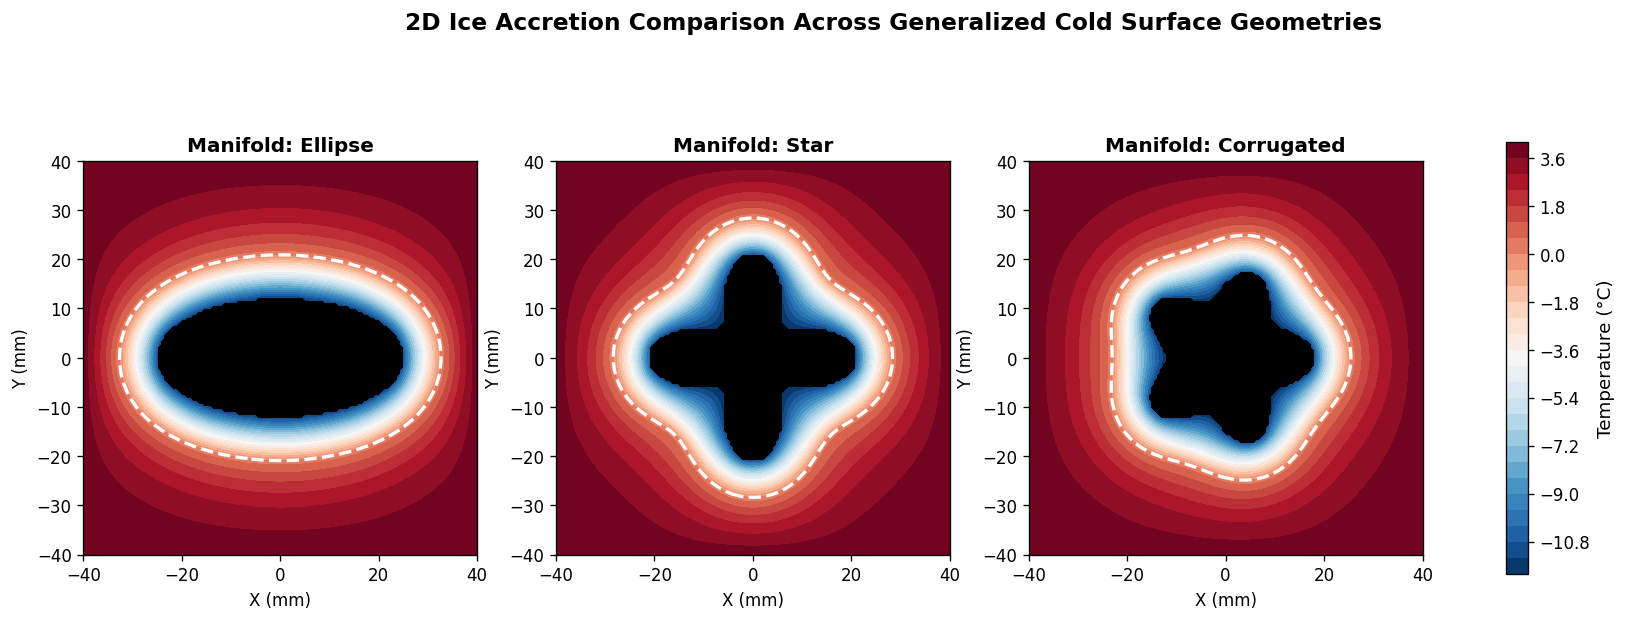

In [5]:
#Code for comparing corrugated, star and ellipse manifold

import numpy as np
import matplotlib.pyplot as plt

def solve_2d_stefan_arbitrary_manifold(
    Nx=140, Ny=140,           # Spatial resolution
    L=0.08,                   # Domain dimensions (8 cm x 8 cm)
    t_final=600.0,            # Simulation duration (10 minutes)
    T_cold=-12.0,             # Cold manifold surface temperature (°C)
    T_ambient=4.0,            # Ambient water temperature (°C)
    manifold_type='ellipse'   # Options: 'ellipse', 'star', or 'corrugated'
):
    """
    2D Enthalpy-Based Phase-Change Solver on Arbitrary Cold Surface Manifolds.
    Handles general shapes including Ellipses, Stars, and Corrugated surfaces.
    """
    # 1. 2D Spatial Grid Setup
    x = np.linspace(-L/2, L/2, Nx)
    y = np.linspace(-L/2, L/2, Ny)
    dx = x[1] - x[0]
    dy = y[1] - y[0]
    X, Y = np.meshgrid(x, y)

    # 2. Geometry Masks for General Manifold Shapes
    R_grid = np.sqrt(X**2 + Y**2)
    Theta_grid = np.arctan2(Y, X)

    if manifold_type == 'ellipse':
        # Elliptical manifold (semi-major axis a = 25mm, semi-minor axis b = 12mm)
        a, b = 0.025, 0.012
        manifold_mask = (X / a)**2 + (Y / b)**2 <= 1.0

    elif manifold_type == 'star':
        # 4-pointed star manifold (base radius = 15mm, star arm amplitude = 6mm)
        r_surface = 0.015 + 0.006 * np.cos(4 * Theta_grid)
        manifold_mask = R_grid <= r_surface

    elif manifold_type == 'corrugated':
        # 5-lobed corrugated manifold (base radius = 15mm, ripple amplitude = 3mm)
        r_surface = 0.015 + 0.003 * np.cos(5 * Theta_grid)
        manifold_mask = R_grid <= r_surface

    else:
        raise ValueError("Invalid manifold_type. Choose 'ellipse', 'star', or 'corrugated'.")

    # 3. Thermophysical Properties & Numerical Parameters
    L_f = 333500.0        # Latent heat of fusion for water (J/kg)
    dT = 0.5              # Regularization transition window (°C)

    # Dynamic Stable Time-Stepping (2D Explicit Courant/Fourier Condition)
    alpha_max = 2.22 / (917.0 * 2100.0)  # Ice thermal diffusivity
    dt = 0.2 * (dx**2 * dy**2) / (alpha_max * (dx**2 + dy**2))
    n_steps = int(t_final / dt)

    # 4. State Vector Initialization
    T = np.full((Ny, Nx), T_ambient, dtype=np.float64)
    T[manifold_mask] = T_cold  # Apply Dirichlet boundary condition on interior manifold

    # 5. Time Integration Loop (2D Conservative Finite Difference)
    for step in range(n_steps):
        # Continuous phase fraction: 0 (ice), 1 (water)
        phi = 0.5 * (1.0 + np.tanh(T / dT))

        # Thermophysical equations of state with 4°C density anomaly
        rho = (1.0 - phi) * 917.0 + phi * (999.84 + 0.017 * np.maximum(T, 0.0))
        c_p = (1.0 - phi) * 2100.0 + phi * 4184.0
        c_eff = c_p + (L_f / (np.sqrt(np.pi) * dT)) * np.exp(-(T / dT)**2)
        k = (1.0 - phi) * 2.22 + phi * 0.56

        # 2D Conductive Flux Discretization
        k_east = 0.5 * (k[:, 1:] + k[:, :-1])
        flux_x = k_east * (T[:, 1:] - T[:, :-1]) / dx

        k_north = 0.5 * (k[1:, :] + k[:-1, :])
        flux_y = k_north * (T[1:, :] - T[:-1, :]) / dy

        # Divergence of flux: div(k * grad(T))
        div_flux = np.zeros_like(T)
        div_flux[:, 1:-1] += (flux_x[:, 1:] - flux_x[:, :-1]) / dx
        div_flux[1:-1, :] += (flux_y[1:, :] - flux_y[:-1, :]) / dy

        # Update interior nodes
        dT_dt = div_flux / (rho * c_eff)
        T += dt * dT_dt

        # Re-enforce Dirichlet Boundary Conditions
        T[manifold_mask] = T_cold
        T[0, :] = T_ambient; T[-1, :] = T_ambient
        T[:, 0] = T_ambient; T[:, -1] = T_ambient

    return X * 1000.0, Y * 1000.0, T, manifold_mask


# -----------------------------------------------------------------------------
# RUN AND PLOT ALL THREE MANIFOLDS (ELLIPSE, STAR, CORRUGATED)
# -----------------------------------------------------------------------------
manifolds = ['ellipse', 'star', 'corrugated']
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), dpi=120)

for ax, m_type in zip(axes, manifolds):
    X_mm, Y_mm, T_final, mask = solve_2d_stefan_arbitrary_manifold(manifold_type=m_type)

    # Temperature contour map
    cf = ax.contourf(X_mm, Y_mm, T_final, levels=30, cmap='RdBu_r')

    # Solid black manifold geometry
    ax.contourf(X_mm, Y_mm, mask, levels=[0.5, 1.0], colors='black')

    # 0°C Phase Front (Dashed White Line)
    ax.contour(X_mm, Y_mm, T_final, levels=[0.0], colors='white', linewidths=2, linestyles='--')

    ax.set_title(f"Manifold: {m_type.capitalize()}", fontsize=12, fontweight='bold')
    ax.set_xlabel("X (mm)")
    ax.set_ylabel("Y (mm)")
    ax.set_aspect('equal')

# Add single shared colorbar
cbar = fig.colorbar(cf, ax=axes.ravel().tolist(), shrink=0.85)
cbar.set_label('Temperature (°C)', fontsize=11)

plt.suptitle("2D Ice Accretion Comparison Across Generalized Cold Surface Geometries", fontsize=14, fontweight='bold', y=1.02)
plt.show()